# 54. Square-Dalitz coordinate conversions

**Objectives:**

- Convert ordinary Dalitz invariants to Laura++ `(m', theta')` with `invariants_to_square_dalitz`
  and back with `square_dalitz_to_invariants`, and confirm the round trip.
- Plot the transformation Jacobian `square_dalitz_jacobian` over the physical `(m', theta')`
  square.
- Demonstrate `fold_thetaprime`, which maps `theta'` onto `[0, 0.5]` for identical-particle
  exchange.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and daughter
indices start at zero. See `docs/square_dalitz.md` for the full convention.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede any numerical work: amplitudes use complex128.

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    fold_thetaprime,
    invariants_to_square_dalitz,
    square_dalitz_jacobian,
    square_dalitz_to_invariants,
)

## 1. Round trip: invariants -> square-Dalitz -> invariants

`D+ -> pi- pi+ pi+` (two identical pi+). Use `pair=(0, 1)`, the literal Laura++
ordered-pair convention (`docs/square_dalitz.md`). Start from a small grid of `(m', theta')`
points inside the open unit square, map to `(s12, s13, s23)`, then convert back and compare.

In [2]:
mother_mass = 1.869
masses = (0.13957, 0.13957, 0.13957)  # (pi-, pi+, pi+)
pair = (0, 1)

mprime = jnp.linspace(0.05, 0.95, 25)
thetaprime = jnp.linspace(0.05, 0.95, 25)
mp_grid, tp_grid = jnp.meshgrid(mprime, thetaprime, indexing="ij")
mp_flat, tp_flat = mp_grid.reshape(-1), tp_grid.reshape(-1)

s12, s13, s23 = square_dalitz_to_invariants(
    mp_flat, tp_flat, mother_mass=mother_mass, masses=masses, pair=pair,
)
mp_back, tp_back = invariants_to_square_dalitz(
    s12, s13, s23, mother_mass=mother_mass, masses=masses, pair=pair,
)

np.testing.assert_allclose(mp_back, mp_flat, atol=1e-9)
np.testing.assert_allclose(tp_back, tp_flat, atol=1e-9)
print(f"Round trip verified on {mp_flat.size} points (max |dm'|={float(jnp.max(jnp.abs(mp_back - mp_flat))):.2e}, "
      f"max |dtheta'|={float(jnp.max(jnp.abs(tp_back - tp_flat))):.2e}).")

Round trip verified on 625 points (max |dm'|=1.80e-16, max |dtheta'|=1.33e-15).


## 2. The transformation Jacobian

`square_dalitz_jacobian` returns `|d(s_ij,s_ik)/d(m',theta')|`, the factor `SquareDalitzGrid`
folds into `PhaseSpaceSample.weights` so that `mean(weights * f)` integrates correctly
(`docs/square_dalitz.md`). It vanishes at `theta'=0,1` (collinear configurations) and grows
near the edges of `m'`.

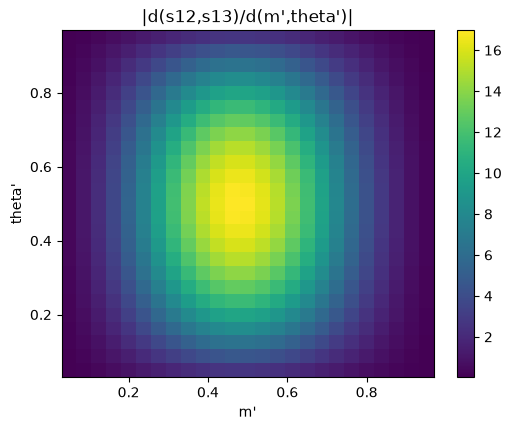

Jacobian range: [0.0422, 16.9635] GeV^4


In [3]:
jacobian = square_dalitz_jacobian(
    mp_flat, tp_flat, mother_mass=mother_mass, masses=masses, pair=pair,
).reshape(mp_grid.shape)

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.pcolormesh(np.asarray(mprime), np.asarray(thetaprime), np.asarray(jacobian).T, shading="auto")
ax.set(xlabel="m'", ylabel="theta'", title="|d(s12,s13)/d(m',theta')|")
fig.colorbar(im, ax=ax)
plt.show()
print(f"Jacobian range: [{float(jnp.min(jacobian)):.4f}, {float(jnp.max(jacobian)):.4f}] GeV^4")

## 3. Folding `theta'` for the identical pi+ pi+ pair

`(0, 1)` here is the identical pi+ pi+ pair, so `theta' -> 1 - theta'` is a physical symmetry
of the Dalitz plot (`square_dalitz_to_invariants`'s docstring). `fold_thetaprime` restricts to
the distinct half `theta' <= 0.5`; a point and its mirror image fold onto the same value.

In [4]:
sample_theta = jnp.array([0.10, 0.35, 0.50, 0.65, 0.90])
mirror_theta = 1.0 - sample_theta
folded = fold_thetaprime(sample_theta)
folded_mirror = fold_thetaprime(mirror_theta)

np.testing.assert_allclose(folded, folded_mirror, atol=1e-12)
for t, tm, f in zip(sample_theta, mirror_theta, folded):
    print(f"theta'={float(t):.2f}  mirror={float(tm):.2f}  fold_thetaprime -> {float(f):.2f}")
print("A point and its exchange mirror fold onto the same value, as expected for pi+ pi+.")

theta'=0.10  mirror=0.90  fold_thetaprime -> 0.10
theta'=0.35  mirror=0.65  fold_thetaprime -> 0.35
theta'=0.50  mirror=0.50  fold_thetaprime -> 0.50
theta'=0.65  mirror=0.35  fold_thetaprime -> 0.35
theta'=0.90  mirror=0.10  fold_thetaprime -> 0.10
A point and its exchange mirror fold onto the same value, as expected for pi+ pi+.


## Continue learning

See [`docs/square_dalitz.md`](../../docs/square_dalitz.md) for the full convention, and
[`docs/backgrounds_and_vetoes.md`](../../docs/backgrounds_and_vetoes.md) for how folding is
used to build efficiency/background maps from limited samples.

Return to [the course guide](TUTORIALS.md).